Problem 1

In [79]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from nltk.translate.bleu_score import sentence_bleu

In [80]:
pairs = []

with open("vast_english_french.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            english = parts[0].lower().strip()
            french = parts[1].lower().strip()
            pairs.append((english, french))

print(len(pairs))
print(pairs[0])

555
('i am cold', "j'ai froid")


In [81]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))

Train: 444
Validation: 111


In [82]:
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

In [83]:
class Vocab:
    def __init__(self):
        self.word2idx = {
            PAD_TOKEN: PAD_IDX,
            SOS_TOKEN: SOS_IDX,
            EOS_TOKEN: EOS_IDX,
            UNK_TOKEN: UNK_IDX
        }
        self.idx2word = {
            PAD_IDX: PAD_TOKEN,
            SOS_IDX: SOS_TOKEN,
            EOS_IDX: EOS_TOKEN,
            UNK_IDX: UNK_TOKEN
        }

    def build_vocab(self, sentences):
        for sentence in sentences:
            for word in sentence.split():
                if word not in self.word2idx:
                    idx = len(self.word2idx)
                    self.word2idx[word] = idx
                    self.idx2word[idx] = word

    def encode(self, sentence, max_len):
        words = sentence.split()
        words = words[:max_len - 2]

        tokens = [SOS_TOKEN] + words + [EOS_TOKEN]

        ids = [
            self.word2idx.get(word, UNK_IDX)
            for word in tokens
        ]

        while len(ids) < max_len:
            ids.append(PAD_IDX)

        return ids

    def decode(self, ids):
        words = []

        for idx in ids:
            word = self.idx2word.get(int(idx), UNK_TOKEN)

            if word == EOS_TOKEN:
                break

            if word not in [PAD_TOKEN, SOS_TOKEN]:
                words.append(word)

        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

In [84]:
english_vocab = Vocab()
french_vocab = Vocab()

english_vocab.build_vocab([pair[0] for pair in train_pairs])
french_vocab.build_vocab([pair[1] for pair in train_pairs])

print("English vocab size:", len(english_vocab))
print("French vocab size:", len(french_vocab))

English vocab size: 894
French vocab size: 993


In [85]:
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 20

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, tgt_sentence = self.pairs[idx]

        src_ids = self.src_vocab.encode(src_sentence, self.max_len)
        tgt_ids = self.tgt_vocab.encode(tgt_sentence, self.max_len)

        return torch.tensor(src_ids), torch.tensor(tgt_ids)

In [86]:
train_dataset = TranslationDataset(
    train_pairs,
    english_vocab,
    french_vocab,
    MAX_LEN
)

val_dataset = TranslationDataset(
    val_pairs,
    english_vocab,
    french_vocab,
    MAX_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64
)

In [87]:
import torch.nn as nn
import random

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

class Encoder(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return hidden


class Decoder(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = len(french_vocab)

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(DEVICE)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

cuda


In [88]:
INPUT_SIZE = len(english_vocab)
OUTPUT_SIZE = len(french_vocab)
EMBED_SIZE = 128
HIDDEN_SIZE = 256

encoder = Encoder(INPUT_SIZE, EMBED_SIZE, HIDDEN_SIZE)
decoder = Decoder(OUTPUT_SIZE, EMBED_SIZE, HIDDEN_SIZE)

model = Seq2Seq(encoder, decoder).to(DEVICE)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=993, bias=True)
  )
)


In [89]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for src, tgt in train_loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        optimizer.zero_grad()

        output = model(src, tgt)

        output = output[:, 1:].reshape(-1, OUTPUT_SIZE)
        tgt_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, tgt in val_loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            output = model(src, tgt, teacher_forcing_ratio=0)

            output = output[:, 1:].reshape(-1, OUTPUT_SIZE)
            tgt_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_loss)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 6.7971 | Val Loss: 6.4302
Epoch 2/10 | Train Loss: 6.0339 | Val Loss: 5.7019
Epoch 3/10 | Train Loss: 5.3282 | Val Loss: 5.5184
Epoch 4/10 | Train Loss: 5.1349 | Val Loss: 5.5251
Epoch 5/10 | Train Loss: 4.9771 | Val Loss: 5.5348
Epoch 6/10 | Train Loss: 4.8833 | Val Loss: 5.5547
Epoch 7/10 | Train Loss: 4.7825 | Val Loss: 5.5603
Epoch 8/10 | Train Loss: 4.7177 | Val Loss: 5.5889
Epoch 9/10 | Train Loss: 4.6415 | Val Loss: 5.5974
Epoch 10/10 | Train Loss: 4.5353 | Val Loss: 5.5402


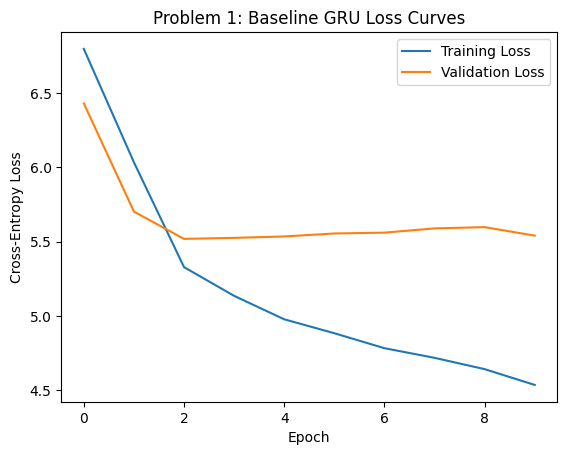

In [90]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 1: Baseline GRU Loss Curves")
plt.legend()
plt.show()

In [91]:
def translate(sentence, model, src_vocab, tgt_vocab, max_len=MAX_LEN):
    model.eval()

    src_ids = src_vocab.encode(sentence.lower().strip(), max_len)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([SOS_IDX]).to(DEVICE)

        predicted_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)

            top1 = output.argmax(1)
            predicted_ids.append(top1.item())

            if top1.item() == EOS_IDX:
                break

            input_token = top1

    return tgt_vocab.decode(predicted_ids)

In [92]:
exact_matches = 0

for english, french in val_pairs:
    prediction = translate(english, model, english_vocab, french_vocab)

    if prediction.strip() == french.strip():
        exact_matches += 1

exact_accuracy = exact_matches / len(val_pairs)

print("Exact Match Accuracy:", exact_accuracy)

Exact Match Accuracy: 0.0


In [93]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

smooth = SmoothingFunction().method1

bleu_scores = []

for english, french in val_pairs:
    prediction = translate(english, model, english_vocab, french_vocab)

    reference = [french.split()]
    candidate = prediction.split()

    bleu = sentence_bleu(
        reference,
        candidate,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    bleu_scores.append(bleu)

average_bleu = np.mean(bleu_scores)

print("Validation BLEU-4:", average_bleu)

Validation BLEU-4: 0.04166243487397596


In [94]:
for i in range(5):
    english, french = val_pairs[i]

    prediction = translate(english, model, english_vocab, french_vocab)

    bleu = sentence_bleu(
        [french.split()],
        prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    exact = prediction.strip() == french.strip()

    print("English:", english)
    print("Target French:", french)
    print("Predicted French:", prediction)
    print("Exact Match:", exact)
    print("BLEU-4:", bleu)
    print("-" * 50)

English: she won a tennis match
Target French: elle a gagné un match de tennis
Predicted French: elle a une une
Exact Match: False
BLEU-4: 0.08025716728928957
--------------------------------------------------
English: the organic market opens at dawn on saturdays
Target French: le marché biologique ouvre à l'aube le samedi
Predicted French: le est est un
Exact Match: False
BLEU-4: 0.029556479778261396
--------------------------------------------------
English: we watch a movie together
Target French: nous regardons un film ensemble
Predicted French: nous avons un une
Exact Match: False
BLEU-4: 0.07440995947486906
--------------------------------------------------
English: the bread at this bakery is always crunchy
Target French: le pain de cette boulangerie est toujours croustillant
Predicted French: le est est un
Exact Match: False
BLEU-4: 0.0351487760467425
--------------------------------------------------
English: we dance at the wedding
Target French: nous dansons au mariage
Pred

Problem 2

In [95]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        self.W_encoder = nn.Linear(hidden_size, hidden_size)
        self.W_decoder = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, encoder_outputs, decoder_hidden):
        decoder_hidden = decoder_hidden[-1].unsqueeze(1)

        scores = self.V(
            torch.tanh(
                self.W_encoder(encoder_outputs)
                + self.W_decoder(decoder_hidden)
            )
        )

        attention_weights = torch.softmax(scores, dim=1)

        context = torch.sum(attention_weights * encoder_outputs, dim=1)

        return context, attention_weights

In [96]:
class AttentionEncoder(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)

        encoder_outputs, hidden = self.gru(embedded)

        return encoder_outputs, hidden

In [97]:
class AttentionDecoder(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hidden_size)

        self.gru = nn.GRU(
            embed_size + hidden_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden, encoder_outputs):
        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        context, attention_weights = self.attention(
            encoder_outputs,
            hidden
        )

        context = context.unsqueeze(1)

        decoder_input = torch.cat(
            [embedded, context],
            dim=2
        )

        output, hidden = self.gru(decoder_input, hidden)

        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, attention_weights

In [98]:
class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = len(french_vocab)

        outputs = torch.zeros(
            batch_size,
            tgt_len,
            tgt_vocab_size
        ).to(DEVICE)

        encoder_outputs, hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [99]:
attn_encoder = AttentionEncoder(
    INPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

attn_decoder = AttentionDecoder(
    OUTPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

attention_model = AttentionSeq2Seq(
    attn_encoder,
    attn_decoder
).to(DEVICE)

print(attention_model)

AttentionSeq2Seq(
  (encoder): AttentionEncoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (W_encoder): Linear(in_features=256, out_features=256, bias=True)
      (W_decoder): Linear(in_features=256, out_features=256, bias=True)
      (V): Linear(in_features=256, out_features=1, bias=True)
    )
    (gru): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=993, bias=True)
  )
)


In [100]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(attention_model.parameters(), lr=0.001)

EPOCHS = 10

attn_train_losses = []
attn_val_losses = []

for epoch in range(EPOCHS):
    attention_model.train()
    total_train_loss = 0

    for src, tgt in train_loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        optimizer.zero_grad()

        output = attention_model(src, tgt)

        output = output[:, 1:].reshape(-1, OUTPUT_SIZE)
        tgt_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(attention_model.parameters(), 1)

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    attention_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, tgt in val_loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            output = attention_model(src, tgt, teacher_forcing_ratio=0)

            output = output[:, 1:].reshape(-1, OUTPUT_SIZE)
            tgt_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_loss)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    attn_train_losses.append(avg_train_loss)
    attn_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 6.6352 | Val Loss: 6.0911
Epoch 2/10 | Train Loss: 5.7647 | Val Loss: 5.8099
Epoch 3/10 | Train Loss: 5.3702 | Val Loss: 5.8246
Epoch 4/10 | Train Loss: 5.2012 | Val Loss: 5.7090
Epoch 5/10 | Train Loss: 5.0472 | Val Loss: 5.7079
Epoch 6/10 | Train Loss: 4.9090 | Val Loss: 5.7697
Epoch 7/10 | Train Loss: 4.8075 | Val Loss: 5.6207
Epoch 8/10 | Train Loss: 4.6962 | Val Loss: 5.6190
Epoch 9/10 | Train Loss: 4.5997 | Val Loss: 5.5389
Epoch 10/10 | Train Loss: 4.4547 | Val Loss: 5.5038


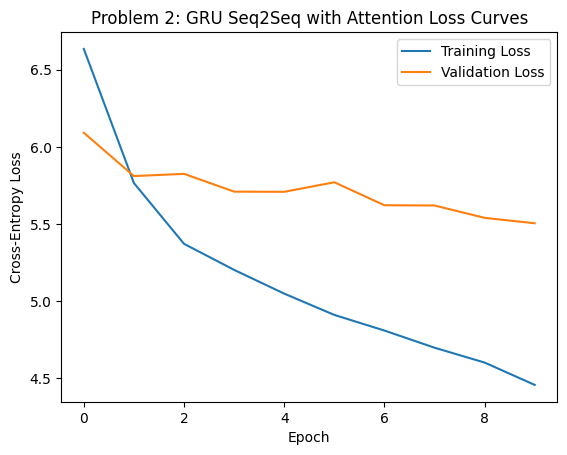

In [101]:
plt.figure()
plt.plot(attn_train_losses, label="Training Loss")
plt.plot(attn_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 2: GRU Seq2Seq with Attention Loss Curves")
plt.legend()
plt.show()

In [102]:
def translate_attention(sentence, model, src_vocab, tgt_vocab, max_len=MAX_LEN):
    model.eval()

    src_ids = src_vocab.encode(sentence.lower().strip(), max_len)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    predicted_ids = []
    all_attention_weights = []

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

        input_token = torch.tensor([SOS_IDX]).to(DEVICE)

        for _ in range(max_len):
            output, hidden, attention_weights = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

            top1 = output.argmax(1)

            predicted_ids.append(top1.item())
            all_attention_weights.append(
                attention_weights.squeeze(0).squeeze(-1).cpu().numpy()
            )

            if top1.item() == EOS_IDX:
                break

            input_token = top1

    prediction = tgt_vocab.decode(predicted_ids)

    return prediction, all_attention_weights

In [103]:
attn_exact_matches = 0

for english, french in val_pairs:
    prediction, _ = translate_attention(
        english,
        attention_model,
        english_vocab,
        french_vocab
    )

    if prediction.strip() == french.strip():
        attn_exact_matches += 1

attn_exact_accuracy = attn_exact_matches / len(val_pairs)

print("Attention Exact Match Accuracy:", attn_exact_accuracy)

Attention Exact Match Accuracy: 0.0


In [104]:
attn_bleu_scores = []

for english, french in val_pairs:
    prediction, _ = translate_attention(
        english,
        attention_model,
        english_vocab,
        french_vocab
    )

    bleu = sentence_bleu(
        [french.split()],
        prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    attn_bleu_scores.append(bleu)

attn_average_bleu = np.mean(attn_bleu_scores)

print("Attention Validation BLEU-4:", attn_average_bleu)

Attention Validation BLEU-4: 0.038818649864689074


In [105]:
for i in range(5):
    english, french = val_pairs[i]

    prediction, attention_weights = translate_attention(
        english,
        attention_model,
        english_vocab,
        french_vocab
    )

    bleu = sentence_bleu(
        [french.split()],
        prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    exact = prediction.strip() == french.strip()

    print("English:", english)
    print("Target French:", french)
    print("Predicted French:", prediction)
    print("Exact Match:", exact)
    print("BLEU-4:", bleu)
    print("-" * 50)

English: she won a tennis match
Target French: elle a gagné un match de tennis
Predicted French: il a une une un
Exact Match: False
BLEU-4: 0.04282963710525157
--------------------------------------------------
English: the organic market opens at dawn on saturdays
Target French: le marché biologique ouvre à l'aube le samedi
Predicted French: le avons est est
Exact Match: False
BLEU-4: 0.029556479778261396
--------------------------------------------------
English: we watch a movie together
Target French: nous regardons un film ensemble
Predicted French: nous avons un un un
Exact Match: False
BLEU-4: 0.06389431042462725
--------------------------------------------------
English: the bread at this bakery is always crunchy
Target French: le pain de cette boulangerie est toujours croustillant
Predicted French: le pain est est
Exact Match: False
BLEU-4: 0.069172428217611
--------------------------------------------------
English: we dance at the wedding
Target French: nous dansons au maria

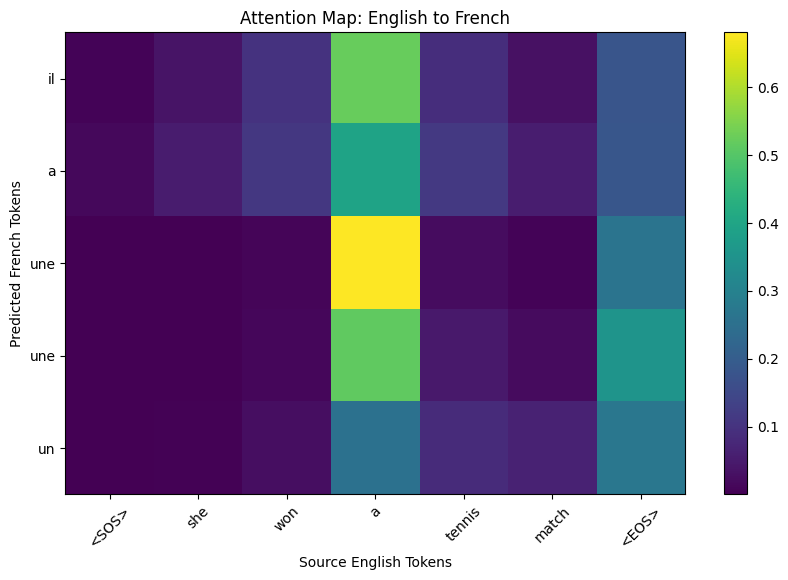

In [106]:
english, french = val_pairs[0]

prediction, attention_weights = translate_attention(
    english,
    attention_model,
    english_vocab,
    french_vocab
)

src_tokens = [SOS_TOKEN] + english.lower().strip().split()[:MAX_LEN-2] + [EOS_TOKEN]
pred_tokens = prediction.split()

attention_matrix = np.array(attention_weights)

attention_matrix = attention_matrix[:len(pred_tokens), :len(src_tokens)]

plt.figure(figsize=(10, 6))
plt.imshow(attention_matrix, aspect="auto")
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45)
plt.yticks(range(len(pred_tokens)), pred_tokens)
plt.xlabel("Source English Tokens")
plt.ylabel("Predicted French Tokens")
plt.title("Attention Map: English to French")
plt.colorbar()
plt.show()

In [107]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline GRU",
        "GRU + Attention"
    ],
    "Exact Match Accuracy": [
        exact_accuracy,
        attn_exact_accuracy
    ],
    "BLEU-4": [
        average_bleu,
        attn_average_bleu
    ],
    "Final Validation Loss": [
        val_losses[-1],
        attn_val_losses[-1]
    ]
})

comparison

,Model,Exact Match Accuracy,BLEU-4,Final Validation Loss
0,Baseline GRU,0.0,0.041662,5.540231
1,GRU + Attention,0.0,0.038819,5.503758


Problem 3

In [108]:
fr_en_train_pairs = [(fr, en) for en, fr in train_pairs]
fr_en_val_pairs = [(fr, en) for en, fr in val_pairs]

In [109]:
fr_src_vocab = Vocab()
en_tgt_vocab = Vocab()

fr_src_vocab.build_vocab([pair[0] for pair in fr_en_train_pairs])
en_tgt_vocab.build_vocab([pair[1] for pair in fr_en_train_pairs])

print("French source vocab:", len(fr_src_vocab))
print("English target vocab:", len(en_tgt_vocab))

French source vocab: 993
English target vocab: 894


In [110]:
fr_en_train_dataset = TranslationDataset(
    fr_en_train_pairs,
    fr_src_vocab,
    en_tgt_vocab,
    MAX_LEN
)

fr_en_val_dataset = TranslationDataset(
    fr_en_val_pairs,
    fr_src_vocab,
    en_tgt_vocab,
    MAX_LEN
)

fr_en_train_loader = DataLoader(
    fr_en_train_dataset,
    batch_size=64,
    shuffle=True
)

fr_en_val_loader = DataLoader(
    fr_en_val_dataset,
    batch_size=64
)

In [111]:
class Seq2SeqFlexible(nn.Module):
    def __init__(self, encoder, decoder, target_vocab_size):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.target_vocab_size = target_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]

        outputs = torch.zeros(
            batch_size,
            tgt_len,
            self.target_vocab_size
        ).to(DEVICE)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [112]:
FR_INPUT_SIZE = len(fr_src_vocab)
EN_OUTPUT_SIZE = len(en_tgt_vocab)

fr_en_encoder = Encoder(
    FR_INPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

fr_en_decoder = Decoder(
    EN_OUTPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

fr_en_baseline_model = Seq2SeqFlexible(
    fr_en_encoder,
    fr_en_decoder,
    EN_OUTPUT_SIZE
).to(DEVICE)

print(fr_en_baseline_model)

Seq2SeqFlexible(
  (encoder): Encoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=894, bias=True)
  )
)


In [113]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(fr_en_baseline_model.parameters(), lr=0.001)

EPOCHS = 10

fr_en_base_train_losses = []
fr_en_base_val_losses = []

for epoch in range(EPOCHS):
    fr_en_baseline_model.train()
    total_train_loss = 0

    for src, tgt in fr_en_train_loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        optimizer.zero_grad()

        output = fr_en_baseline_model(src, tgt)

        output = output[:, 1:].reshape(-1, EN_OUTPUT_SIZE)
        tgt_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fr_en_baseline_model.parameters(), 1)

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(fr_en_train_loader)

    fr_en_baseline_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, tgt in fr_en_val_loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            output = fr_en_baseline_model(
                src,
                tgt,
                teacher_forcing_ratio=0
            )

            output = output[:, 1:].reshape(-1, EN_OUTPUT_SIZE)
            tgt_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_loss)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(fr_en_val_loader)

    fr_en_base_train_losses.append(avg_train_loss)
    fr_en_base_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 6.6700 | Val Loss: 6.4109
Epoch 2/10 | Train Loss: 5.9237 | Val Loss: 5.4181
Epoch 3/10 | Train Loss: 5.1258 | Val Loss: 5.5120
Epoch 4/10 | Train Loss: 4.9207 | Val Loss: 5.3432
Epoch 5/10 | Train Loss: 4.7669 | Val Loss: 5.3863
Epoch 6/10 | Train Loss: 4.6843 | Val Loss: 5.4073
Epoch 7/10 | Train Loss: 4.5855 | Val Loss: 5.3624
Epoch 8/10 | Train Loss: 4.4726 | Val Loss: 5.3379
Epoch 9/10 | Train Loss: 4.3737 | Val Loss: 5.3453
Epoch 10/10 | Train Loss: 4.2721 | Val Loss: 5.2666


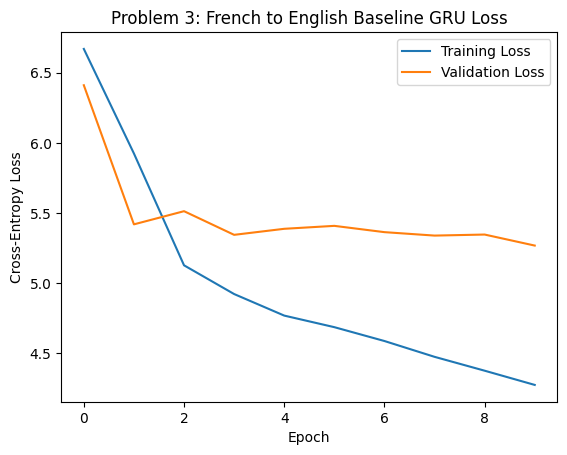

In [114]:
plt.figure()
plt.plot(fr_en_base_train_losses, label="Training Loss")
plt.plot(fr_en_base_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3: French to English Baseline GRU Loss")
plt.legend()
plt.show()

In [115]:
def translate_baseline_flexible(sentence, model, src_vocab, tgt_vocab, max_len=MAX_LEN):
    model.eval()

    src_ids = src_vocab.encode(sentence.lower().strip(), max_len)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    predicted_ids = []

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([SOS_IDX]).to(DEVICE)

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)

            top1 = output.argmax(1)

            predicted_ids.append(top1.item())

            if top1.item() == EOS_IDX:
                break

            input_token = top1

    return tgt_vocab.decode(predicted_ids)

In [116]:
fr_en_base_exact_matches = 0
fr_en_base_bleu_scores = []

for french, english in fr_en_val_pairs:
    prediction = translate_baseline_flexible(
        french,
        fr_en_baseline_model,
        fr_src_vocab,
        en_tgt_vocab
    )

    if prediction.strip() == english.strip():
        fr_en_base_exact_matches += 1

    bleu = sentence_bleu(
        [english.split()],
        prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    fr_en_base_bleu_scores.append(bleu)

fr_en_base_exact_accuracy = fr_en_base_exact_matches / len(fr_en_val_pairs)
fr_en_base_average_bleu = np.mean(fr_en_base_bleu_scores)

print("French -> English Baseline Exact Accuracy:", fr_en_base_exact_accuracy)
print("French -> English Baseline BLEU-4:", fr_en_base_average_bleu)

French -> English Baseline Exact Accuracy: 0.0
French -> English Baseline BLEU-4: 0.05535862328689245


In [117]:
class AttentionSeq2SeqFlexible(nn.Module):
    def __init__(self, encoder, decoder, target_vocab_size):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.target_vocab_size = target_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]

        outputs = torch.zeros(
            batch_size,
            tgt_len,
            self.target_vocab_size
        ).to(DEVICE)

        encoder_outputs, hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [118]:
fr_en_attn_encoder = AttentionEncoder(
    FR_INPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

fr_en_attn_decoder = AttentionDecoder(
    EN_OUTPUT_SIZE,
    EMBED_SIZE,
    HIDDEN_SIZE
)

fr_en_attention_model = AttentionSeq2SeqFlexible(
    fr_en_attn_encoder,
    fr_en_attn_decoder,
    EN_OUTPUT_SIZE
).to(DEVICE)

print(fr_en_attention_model)

AttentionSeq2SeqFlexible(
  (encoder): AttentionEncoder(
    (embedding): Embedding(993, 128, padding_idx=0)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(894, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (W_encoder): Linear(in_features=256, out_features=256, bias=True)
      (W_decoder): Linear(in_features=256, out_features=256, bias=True)
      (V): Linear(in_features=256, out_features=1, bias=True)
    )
    (gru): GRU(384, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=894, bias=True)
  )
)


In [119]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(fr_en_attention_model.parameters(), lr=0.001)

EPOCHS = 10

fr_en_attn_train_losses = []
fr_en_attn_val_losses = []

for epoch in range(EPOCHS):
    fr_en_attention_model.train()
    total_train_loss = 0

    for src, tgt in fr_en_train_loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        optimizer.zero_grad()

        output = fr_en_attention_model(src, tgt)

        output = output[:, 1:].reshape(-1, EN_OUTPUT_SIZE)
        tgt_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fr_en_attention_model.parameters(), 1)

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(fr_en_train_loader)

    fr_en_attention_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, tgt in fr_en_val_loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            output = fr_en_attention_model(
                src,
                tgt,
                teacher_forcing_ratio=0
            )

            output = output[:, 1:].reshape(-1, EN_OUTPUT_SIZE)
            tgt_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_loss)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(fr_en_val_loader)

    fr_en_attn_train_losses.append(avg_train_loss)
    fr_en_attn_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 6.4653 | Val Loss: 5.7247
Epoch 2/10 | Train Loss: 5.4781 | Val Loss: 5.3711
Epoch 3/10 | Train Loss: 5.0745 | Val Loss: 5.3441
Epoch 4/10 | Train Loss: 4.9152 | Val Loss: 5.2920
Epoch 5/10 | Train Loss: 4.8014 | Val Loss: 5.2792
Epoch 6/10 | Train Loss: 4.6992 | Val Loss: 5.3298
Epoch 7/10 | Train Loss: 4.5949 | Val Loss: 5.2762
Epoch 8/10 | Train Loss: 4.4973 | Val Loss: 5.2606
Epoch 9/10 | Train Loss: 4.4226 | Val Loss: 5.2612
Epoch 10/10 | Train Loss: 4.2623 | Val Loss: 5.2124


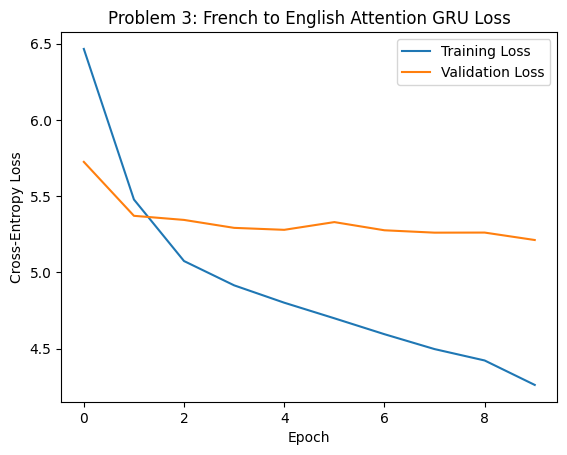

In [120]:
plt.figure()
plt.plot(fr_en_attn_train_losses, label="Training Loss")
plt.plot(fr_en_attn_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3: French to English Attention GRU Loss")
plt.legend()
plt.show()

In [121]:
def translate_attention_flexible(sentence, model, src_vocab, tgt_vocab, max_len=MAX_LEN):
    model.eval()

    src_ids = src_vocab.encode(sentence.lower().strip(), max_len)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    predicted_ids = []
    all_attention_weights = []

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

        input_token = torch.tensor([SOS_IDX]).to(DEVICE)

        for _ in range(max_len):
            output, hidden, attention_weights = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

            top1 = output.argmax(1)

            predicted_ids.append(top1.item())

            all_attention_weights.append(
                attention_weights.squeeze(0).squeeze(-1).cpu().numpy()
            )

            if top1.item() == EOS_IDX:
                break

            input_token = top1

    prediction = tgt_vocab.decode(predicted_ids)

    return prediction, all_attention_weights

In [122]:
fr_en_attn_exact_matches = 0
fr_en_attn_bleu_scores = []

for french, english in fr_en_val_pairs:
    prediction, _ = translate_attention_flexible(
        french,
        fr_en_attention_model,
        fr_src_vocab,
        en_tgt_vocab
    )

    if prediction.strip() == english.strip():
        fr_en_attn_exact_matches += 1

    bleu = sentence_bleu(
        [english.split()],
        prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    fr_en_attn_bleu_scores.append(bleu)

fr_en_attn_exact_accuracy = fr_en_attn_exact_matches / len(fr_en_val_pairs)
fr_en_attn_average_bleu = np.mean(fr_en_attn_bleu_scores)

print("French -> English Attention Exact Accuracy:", fr_en_attn_exact_accuracy)
print("French -> English Attention BLEU-4:", fr_en_attn_average_bleu)

French -> English Attention Exact Accuracy: 0.0
French -> English Attention BLEU-4: 0.039726621664092014


In [123]:
for i in range(5):
    french, english = fr_en_val_pairs[i]

    base_prediction = translate_baseline_flexible(
        french,
        fr_en_baseline_model,
        fr_src_vocab,
        en_tgt_vocab
    )

    attn_prediction, _ = translate_attention_flexible(
        french,
        fr_en_attention_model,
        fr_src_vocab,
        en_tgt_vocab
    )

    base_bleu = sentence_bleu(
        [english.split()],
        base_prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    attn_bleu = sentence_bleu(
        [english.split()],
        attn_prediction.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    print("French:", french)
    print("Target English:", english)
    print("Baseline Prediction:", base_prediction)
    print("Baseline BLEU:", base_bleu)
    print("Attention Prediction:", attn_prediction)
    print("Attention BLEU:", attn_bleu)
    print("-" * 60)

French: elle a gagné un match de tennis
Target English: she won a tennis match
Baseline Prediction: she wears a a
Baseline BLEU: 0.07440995947486906
Attention Prediction: they speak a a a
Attention BLEU: 0.05372849659117709
------------------------------------------------------------
French: le marché biologique ouvre à l'aube le samedi
Target English: the organic market opens at dawn on saturdays
Baseline Prediction: the are is a
Baseline BLEU: 0.029556479778261396
Attention Prediction: the are is to the
Attention BLEU: 0.029486824119076216
------------------------------------------------------------
French: nous regardons un film ensemble
Target English: we watch a movie together
Baseline Prediction: we are the a
Baseline BLEU: 0.07440995947486906
Attention Prediction: she is a a
Attention BLEU: 0.06257106818159155
------------------------------------------------------------
French: le pain de cette boulangerie est toujours croustillant
Target English: the bread at this bakery is alw

In [124]:
final_results = pd.DataFrame({
    "Direction": [
        "English -> French",
        "English -> French",
        "French -> English",
        "French -> English"
    ],
    "Model": [
        "Baseline GRU",
        "GRU + Attention",
        "Baseline GRU",
        "GRU + Attention"
    ],
    "Final Validation Loss": [
        val_losses[-1],
        attn_val_losses[-1],
        fr_en_base_val_losses[-1],
        fr_en_attn_val_losses[-1]
    ],
    "Exact Match Accuracy": [
        exact_accuracy,
        attn_exact_accuracy,
        fr_en_base_exact_accuracy,
        fr_en_attn_exact_accuracy
    ],
    "BLEU-4": [
        average_bleu,
        attn_average_bleu,
        fr_en_base_average_bleu,
        fr_en_attn_average_bleu
    ]
})

final_results

,Direction,Model,Final Validation Loss,Exact Match Accuracy,BLEU-4
0,English -> French,Baseline GRU,5.540231,0.0,0.041662
1,English -> French,GRU + Attention,5.503758,0.0,0.038819
2,French -> English,Baseline GRU,5.266620,0.0,0.055359
3,French -> English,GRU + Attention,5.212420,0.0,0.039727
